# Estimation of the pair correlation function of a point process

In [1]:
import sys
sys.path.append("../..")
from src.point_process import *
import matplotlib.pyplot as plt
import json

**Simulating a Thomas process**

In [2]:
with open('../../parameters/thomas-process-m-02.json', 'r') as file:
    params = json.load(file)

In [3]:
W = params['W']
w, h = W
lam_p = params['lam_p']
nu = params['nu'] 
sig = params['sig']

In [4]:
thomas_process = ThomasProcess(lam_p, nu, sig)
parents, points_thomas = thomas_process.generate(W, seed=42)

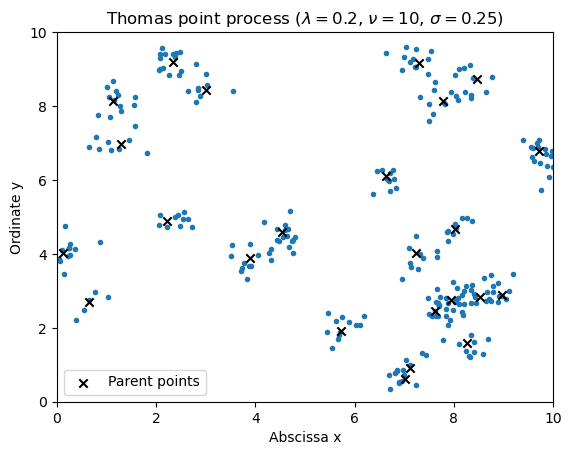

In [5]:
display(parents, points_thomas, window=(10, 10), title=fr"Thomas point process ($\lambda = {lam_p}$, $\nu = {nu}$, $\sigma = {sig}$)")

**Estimating the p.c.f**

Here, we're using R's `pcf` function, that automatically chooses a convenient radius range.

In [6]:
r_values, g_values = g(points_thomas, W)

R[write to console]: Loading required package: spatstat.data

R[write to console]: Loading required package: spatstat.univar

R[write to console]: spatstat.univar 3.1-2

R[write to console]: Loading required package: spatstat.geom

R[write to console]: spatstat.geom 3.3-6

R[write to console]: Loading required package: spatstat.random

R[write to console]: spatstat.random 3.3-3

R[write to console]: Loading required package: spatstat.explore

R[write to console]: Loading required package: nlme

R[write to console]: spatstat.explore 3.4-2

R[write to console]: Loading required package: spatstat.model

R[write to console]: Loading required package: rpart

R[write to console]: spatstat.model 3.3-5

R[write to console]: Loading required package: spatstat.linnet

R[write to console]: spatstat.linnet 3.2-5

R[write to console]: 
spatstat 3.3-2 
For an introduction to spatstat, type ‘beginner’ 


R[write to console]: In addition: 
R[write to console]: Warning messages:

R[write to console]: 1

In [7]:
g_theo_values = 1 + np.exp(-r_values**2/(4*sig**2)) / (4*np.pi*lam_p*sig**2)

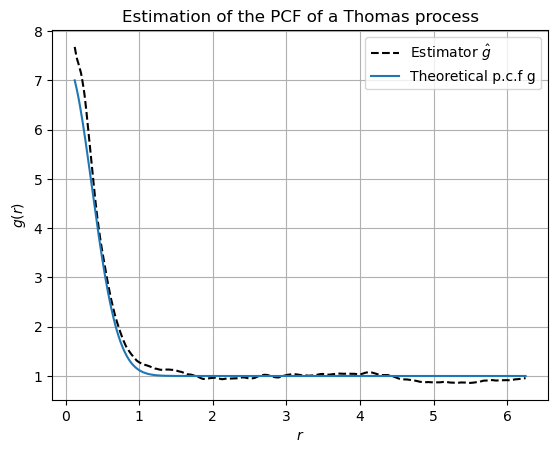

<Figure size 640x480 with 0 Axes>

In [11]:
threshold = 10  # For radii smaller than the bandwidth, the estimator explodes

plt.plot(r_values[threshold:], g_values[threshold:], color='black', linestyle='--', label=r'Estimator $\hat{g}$')
plt.plot(r_values[threshold:], g_theo_values[threshold:], label=r'Theoretical p.c.f g')
plt.xlabel('$r$')
plt.ylabel(r'$g(r)$')

plt.legend()
plt.grid(True)
plt.title('Estimation of the PCF of a Thomas process')
plt.show()
plt.savefig('../../img/pcf-estim-1.eps', format='eps')